<a href="https://colab.research.google.com/github/nurgissas/ML-personal-learning/blob/main/day05_xgboost_house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 5 — Trees & boosting — your first Kaggle submission
**Deliverable checklist — your finished notebook must contain:**
1. ✅ XGBoost baseline trained on House Prices
2. ✅ submission.csv created
3. ✅ Submitted on Kaggle — leaderboard score recorded here
4. ✅ Top-10 feature importance plot + one iteration

> Work top to bottom. **EXAMPLE** cells are done for you — copy the pattern. **TODO** cells are yours. Struggle 30+ min before opening the ✅ Solution sketch in the study app.

**📚 Coding references** *(theory is the videos' job; these teach the code)*: [XGBoost Python intro](https://xgboost.readthedocs.io/en/stable/python/python_intro.html) · [Kaggle Learn: XGBoost lesson](https://www.kaggle.com/learn/intermediate-machine-learning) (interactive)

In [ ]:
import pandas as pd, os

# Get data — pick ONE (join the competition on Kaggle first!):
# A) kagglehub:
import kagglehub
kagglehub.login()
p = kagglehub.competition_download('house-prices-advanced-regression-techniques')
tr = pd.read_csv(os.path.join(p,'train.csv')); te = pd.read_csv(os.path.join(p,'test.csv'))
# B) Google Drive (if you downloaded manually):
# tr = pd.read_csv('/content/drive/MyDrive/ML-30/05/train.csv'); te = ...
tr.shape, te.shape

100%|██████████| 199k/199k [00:00<00:00, 64.9MB/s]

Extracting files...


((1460, 81), (1459, 80))

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
from xgboost import XGBRegressor
y = tr['SalePrice']
X = tr.select_dtypes('number').drop(columns=['SalePrice','Id']).fillna(tr.median(numeric_only=True))
model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4).fit(X, y)

In [ ]:
X.head()
print(X.isna().sum())

MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
dtype: int64


In [37]:
# TODO — predict on test.csv and build the submission file
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
Xte_kaggle = te[X.columns].fillna(tr.median(numeric_only=True))
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size = 0.8, test_size = 0.2, random_state=0)
# print(type(te))
model.fit(Xtr, ytr)
pred = model.predict(Xte)
sub_pred = model.predict(Xte_kaggle)
print(mean_absolute_error(pred, yte))

submission = pd.DataFrame({'Id': te.Id, "SalePrice": sub_pred})
submission.to_csv('submission.csv', index=False)

16943.640625


In [39]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model_1 = XGBRegressor(n_estimators = 750, learning_rate=0.03, max_depth=6)
model_1.fit(Xtr, ytr)

pred_1 = model_1.predict(Xte)
print(mean_absolute_error(pred_1, yte))

17499.482421875


my kaggle record score: `0.14225`

<Axes: >

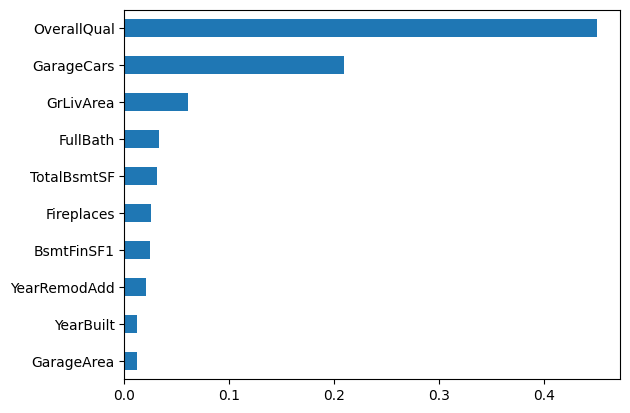

In [29]:
# TODO — plot top-10 feature importances
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
imp.tail(10).plot.barh()
